In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
sns.set_theme(style="whitegrid", palette="muted")

In [3]:

df = pd.read_csv('./dataset/train.csv');

In [7]:
print("\n" + "="*40)
print("1. DATASET OVERVIEW")
print("="*40)
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("\n--- Data Types & Non-Null Counts ---")
df.info()


1. DATASET OVERVIEW
Total Rows: 77299
Total Columns: 11

--- Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  str    
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  str    
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  str    
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  str    
 8   Landmarks      77299 non-null  str    
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 6.5 MB


In [8]:
print("\n" + "="*40)
print("2. MISSING VALUES")
print("="*40)
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])


2. MISSING VALUES
RoadType        600
Temperature    2495
Weather         797
dtype: int64


In [9]:
print("\n" + "="*40)
print("3. SUMMARY STATISTICS (Numerical)")
print("="*40)
display(df.describe())


3. SUMMARY STATISTICS (Numerical)


,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


In [10]:
print("\nExtracting 'hour' and 'minute' from timestamp...")
df[['hour', 'minute']] = df['timestamp'].str.split(':', expand=True).astype(float)


Extracting 'hour' and 'minute' from timestamp...


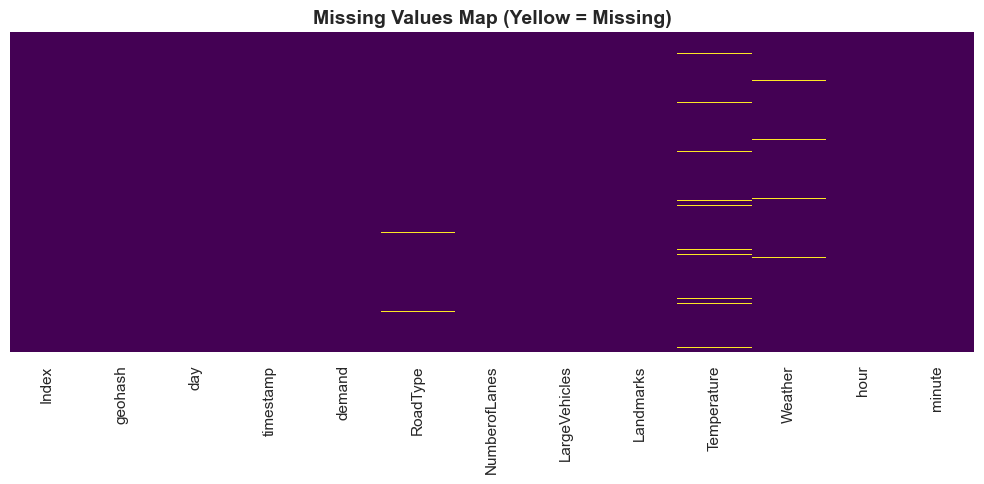

In [12]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Map (Yellow = Missing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

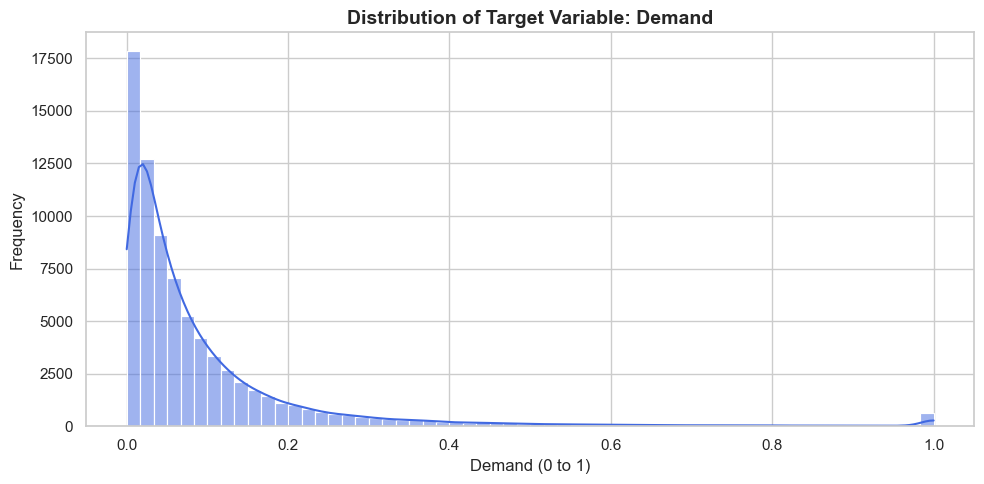

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['demand'].dropna(), bins=60, kde=True, color='royalblue')
plt.title('Distribution of Target Variable: Demand', fontsize=14, fontweight='bold')
plt.xlabel('Demand (0 to 1)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\72vir\AppData\Local\Temp\ipykernel_25800\288518500.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='demand', data=df, palette='Set2')
C:\Users\72vir\AppData\Local\Temp\ipykernel_25800\288518500.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='demand', data=df, palette='Set2')
C:\Users\72vir\AppData\Local\Temp\ipykernel_25800\288518500.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='demand', data=df, palette='Set2')


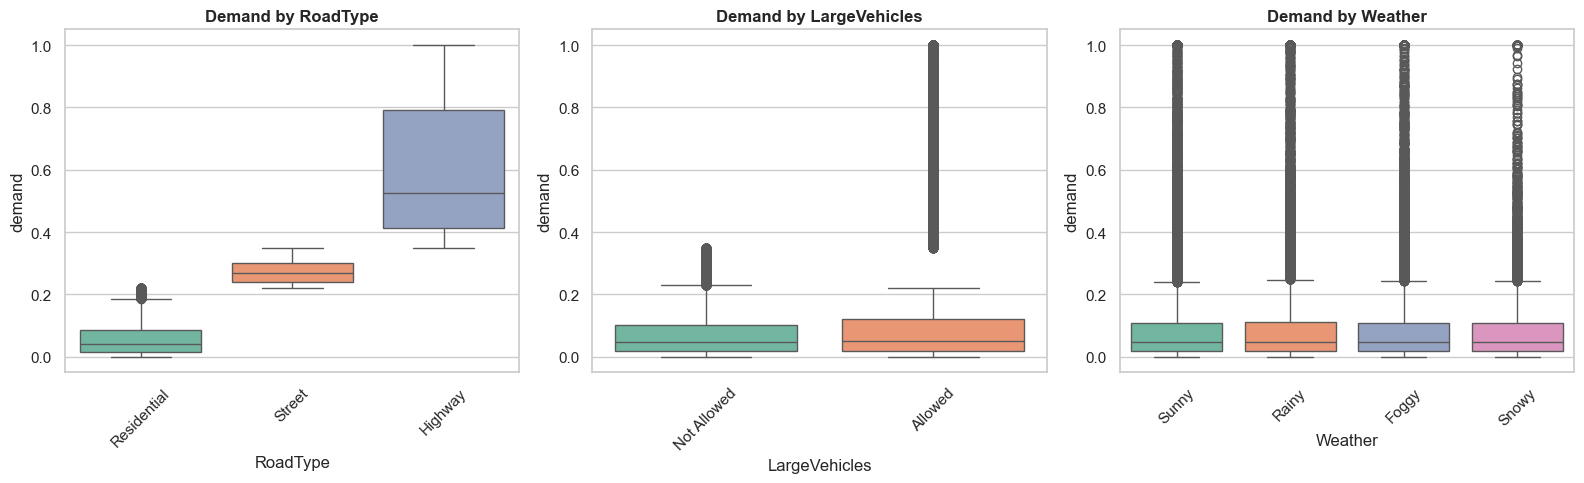

In [14]:
categorical_cols = ['RoadType', 'LargeVehicles', 'Weather']
plt.figure(figsize=(16, 5))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=col, y='demand', data=df, palette='Set2')
    plt.title(f'Demand by {col}', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\72vir\AppData\Local\Temp\ipykernel_25800\1299235011.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='NumberofLanes', y='demand', data=df, palette='Set3')


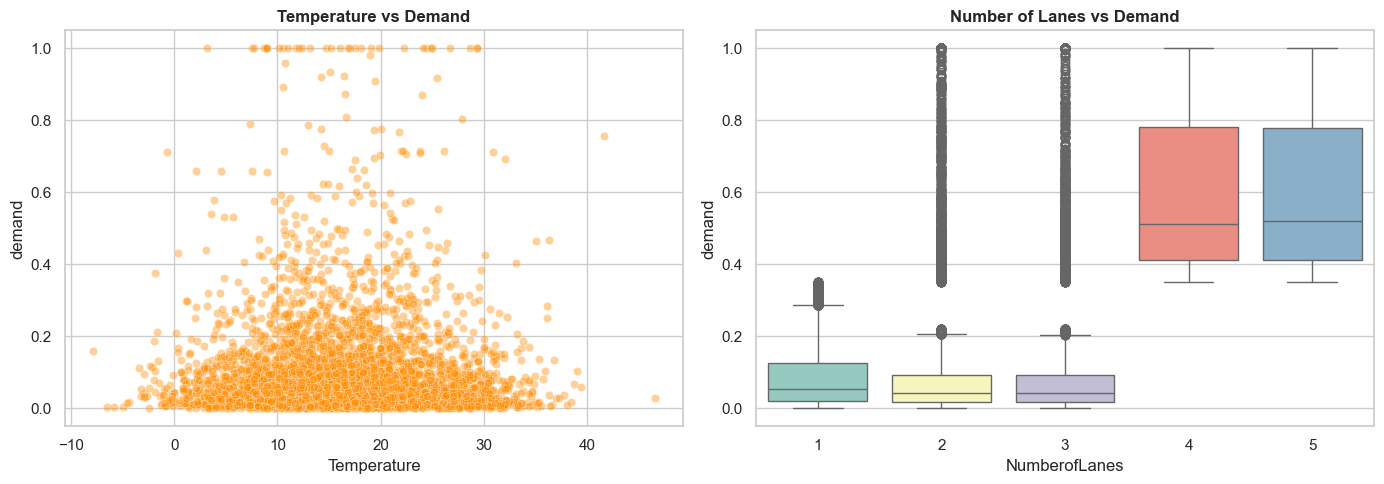

In [16]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sample_df = df.sample(min(len(df), 5000), random_state=42)
sns.scatterplot(x='Temperature', y='demand', data=sample_df, alpha=0.4, color='darkorange')
plt.title('Temperature vs Demand', fontsize=12, fontweight='bold')

plt.subplot(1, 2, 2)
sns.boxplot(x='NumberofLanes', y='demand', data=df, palette='Set3')
plt.title('Number of Lanes vs Demand', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\72vir\AppData\Local\Temp\ipykernel_25800\2484930334.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='geohash', y='demand', data=top_geohashes, palette='rocket')


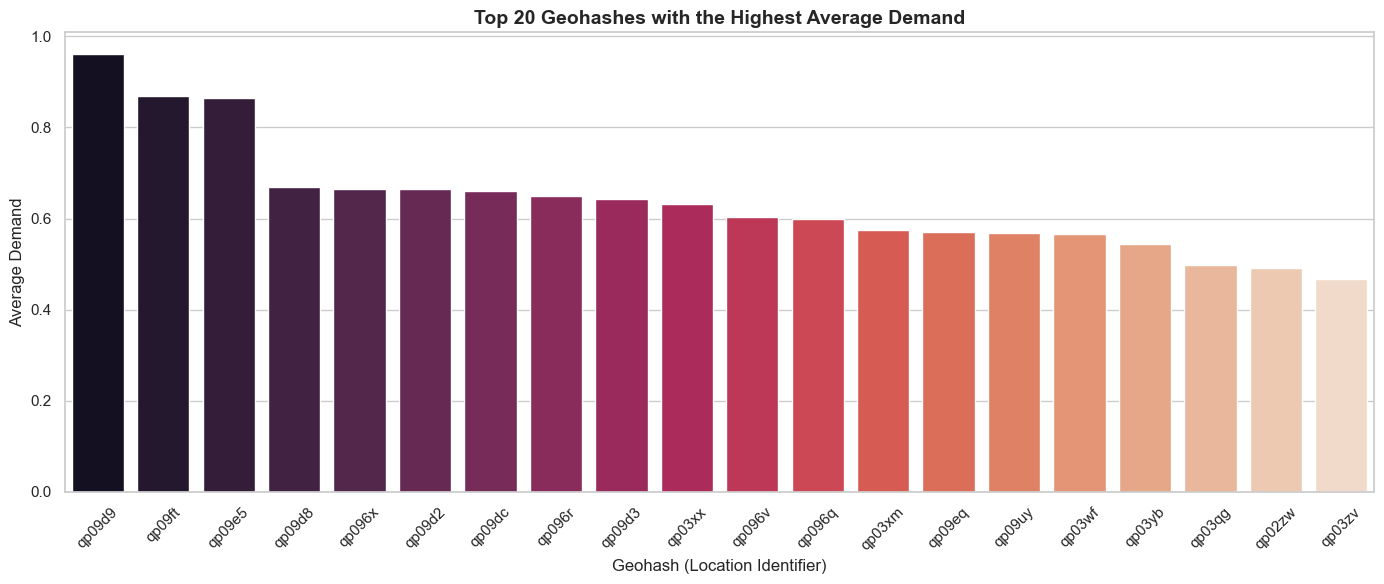

In [17]:
plt.figure(figsize=(14, 6))
top_geohashes = df.groupby('geohash')['demand'].mean().sort_values(ascending=False).head(20).reset_index()
sns.barplot(x='geohash', y='demand', data=top_geohashes, palette='rocket')
plt.title('Top 20 Geohashes with the Highest Average Demand', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Average Demand')
plt.xlabel('Geohash (Location Identifier)')
plt.tight_layout()
plt.show()

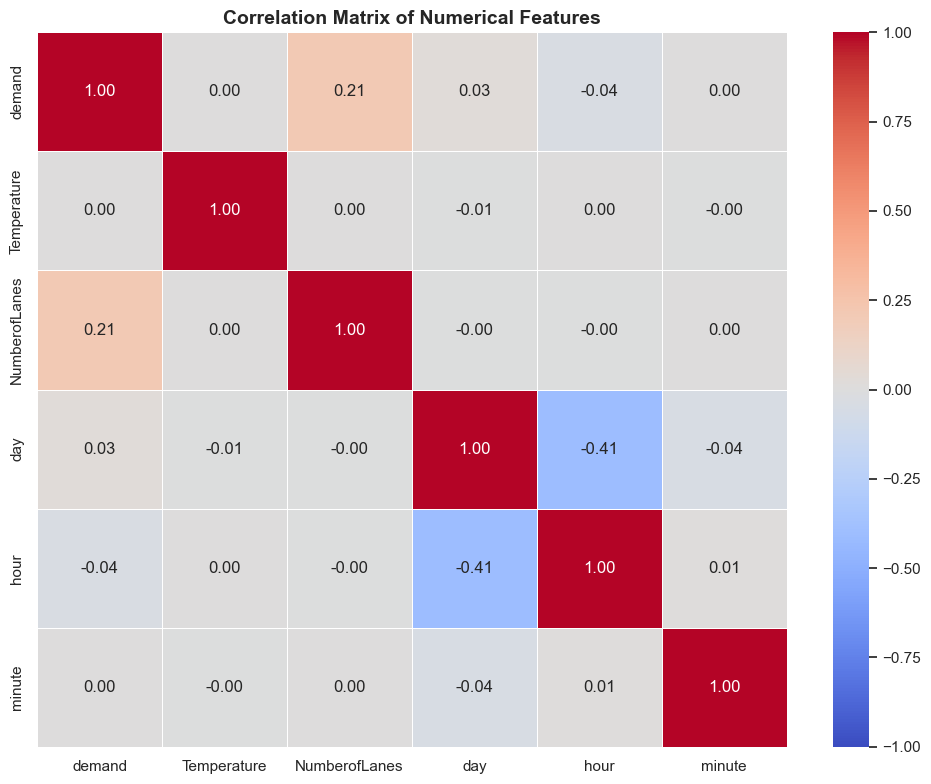

In [18]:
plt.figure(figsize=(10, 8))
corr_cols = ['demand', 'Temperature', 'NumberofLanes', 'day', 'hour', 'minute']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

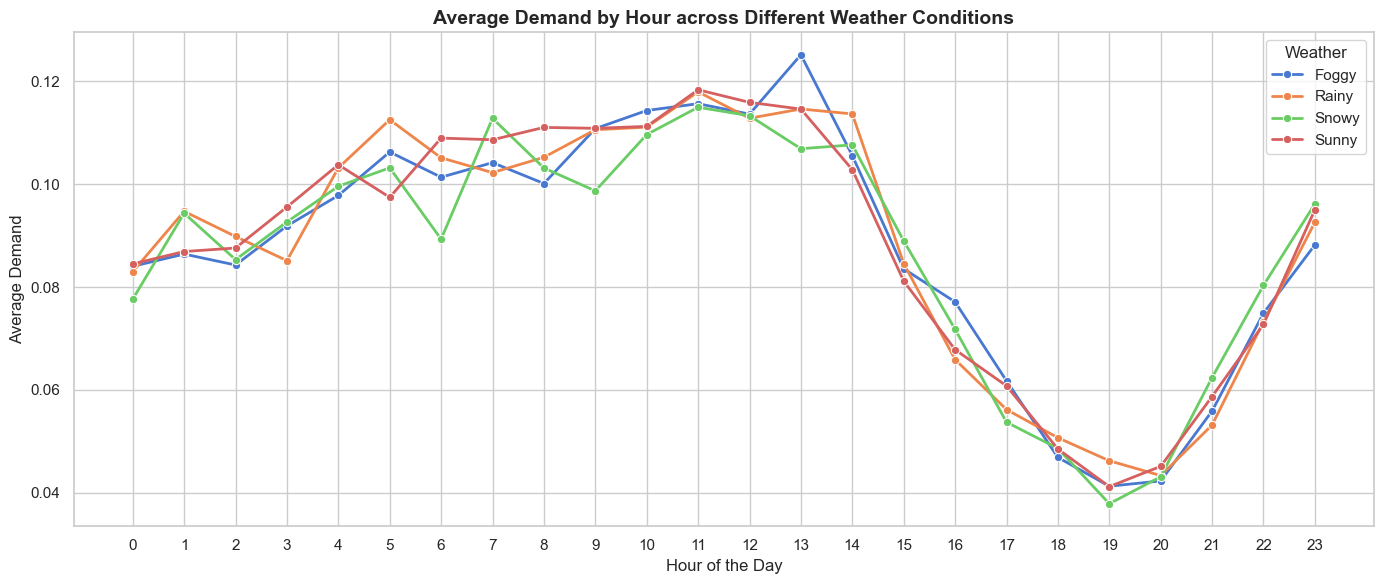

In [19]:
plt.figure(figsize=(14, 6))
clean_weather_df = df.dropna(subset=['Weather', 'demand', 'hour'])
hourly_weather_demand = clean_weather_df.groupby(['hour', 'Weather'])['demand'].mean().reset_index()
sns.lineplot(x='hour', y='demand', hue='Weather', data=hourly_weather_demand, marker='o', linewidth=2)
plt.title('Average Demand by Hour across Different Weather Conditions', fontsize=14, fontweight='bold')
plt.xticks(np.arange(0, 24, 1))
plt.ylabel('Average Demand')
plt.xlabel('Hour of the Day')
plt.legend(title='Weather')
plt.tight_layout()
plt.show()

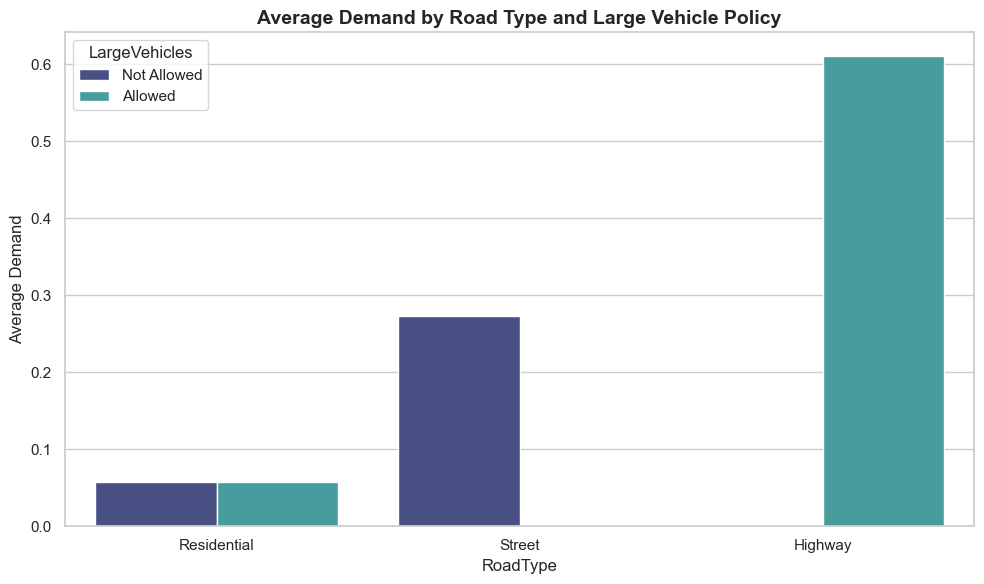

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='RoadType', y='demand', hue='LargeVehicles', data=df, errorbar=None, palette='mako')
plt.title('Average Demand by Road Type and Large Vehicle Policy', fontsize=14, fontweight='bold')
plt.ylabel('Average Demand')
plt.tight_layout()
plt.show()